# S2. Final sweep — 96 vs 128 µm, 8 ROIs, 1000 epochs

The confirmed run: TissueMosaic's own schedule (`warm_up`/`warm_down` 100/100 at
`max_epochs` 1000), weight decay 0, `n_element_min_for_crop` 10 at **both** training
and inference, `n_crops_for_tissue_train` 1024, batch 128, `pixel_size` 2.0.

**This notebook is not really about 96 vs 128.** That question is already well
evidenced — the S1 screen found 128 µm beats every alternative, and gains 3.03× over a
cell-count vector against 96 µm's 1.23×. The open question this run exists to answer is
**transfer**: a model trained on JHH369 alone scored gain **0.33–0.78× on unseen
patients**, i.e. *worse* than clustering cell counts. Five patients in training is the
test of whether that was a data-diversity problem.

> **Read at epoch 399 of 1000.** The LR is still on its peak plateau; the cosine decay
> that usually consolidates a DINO representation runs epochs 900-1000. These numbers
> are a mid-flight comparison, not the final verdict.

### The training set

| ROI | patient | density | biology % | role |
|---|---|---|---|---|
| JHH369ROI1–4 | JHH369 | 5.3–7.2k | 21–41% | the S1 set, kept for continuity |
| JHH387ROI1 | JHH387 | 10,590 | 48.4% | high — dense and signal-rich |
| JHH380ROI1 | JHH380 | 8,262 | 62.1% | high — richest classified signal |
| JHH357ROI5 | JHH357 | 7,396 | **2.2%** | low — dense but signal-poor |
| JHH317ROI2 | JHH317 | **2,643** | 43.7% | low — sparse but signal-rich |

The two low-quality ROIs are low on *orthogonal* axes, so if the model struggles we can
say which failure mode caused it.

### Three tiers of generalisation

Because four training patients contribute other ROIs to the cohort, the 40 untrained
ROIs split into two meaningfully different tests:

| tier | ROIs | patients | isolates |
|---|---|---|---|
| training | 8 | 5 | in-sample fit |
| held-out ROI, **seen** patient | 11 | 4 | a new section of a known patient |
| held-out ROI, **unseen** patient | 29 | 9 | a genuinely new patient |

Gain surviving tier 2 but dying at tier 3 means the failure is patient-level, not
section-level.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import imc_tm

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.width", 250)

CONFIGS = ["final_fov96", "final_fov128"]
EPOCH = 399  # mid-plateau comparison. None = latest available.
# Checkpoints are written at (n*25 - 1), so "epoch 400" is the 399 file.
# NOTE: the cosine decay runs epochs 900-1000, so this model has NOT
# consolidated -- treat every number here as a mid-flight reading.
SEED, RESOLUTION = 0, 1.0
# TissueMosaic's own clustering path (SmartPca -> SmartUmap -> Leiden on the UMAP
# graph). Primary nn=15; nn=100 reported alongside so the clustering dependence is
# visible. NOT the tutorial's nn=100/res=0.1-0.3, which collapses our windows to 1-2
# clusters -- see imc_tm.cluster_embedding_tm.
CLUSTERINGS = {"nn15": 15, "nn100": 100}
PRIMARY = "nn15"
FILTERS = {
    "flat10": None,
    "scaled": 0.5,
}  # None = flat 10; float = fraction of expected

print(imc_tm.compat_summary())
print()
print(imc_tm.final_status().to_string())
print()
for c in CONFIGS:
    print(f"{c:<14s} periodic checkpoints at epochs: {imc_tm.final_periodic_epochs(c)}")

tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt



              fov_um   done  last_epoch  last_loss  periodic_ckpts  latest_ckpt_epoch
name                                                                                 
final_fov96       96  False         766      0.664              30                749
final_fov128     128  False         743      0.364              29                724

final_fov96    periodic checkpoints at epochs: [24, 49, 74, 99, 124, 149, 174, 199, 224, 249, 274, 299, 324, 349, 374, 399, 424, 449, 474, 499, 524, 549, 574, 599, 624, 649, 674, 699, 724, 749]
final_fov128   periodic checkpoints at epochs: [24, 49, 74, 99, 124, 149, 174, 199, 224, 249, 274, 299, 324, 349, 374, 399, 424, 449, 474, 499, 524, 549, 574, 599, 624, 649, 674, 699, 724]


## Loss curves

Both ran the identical schedule, so these are directly comparable. Watch for the
plateau ending at epoch 900 — the cosine decay tail is where DINO usually consolidates.
A loss that flattens *and* an embedding that degrades is the collapse signature; a loss
that keeps falling through the tail is healthy.

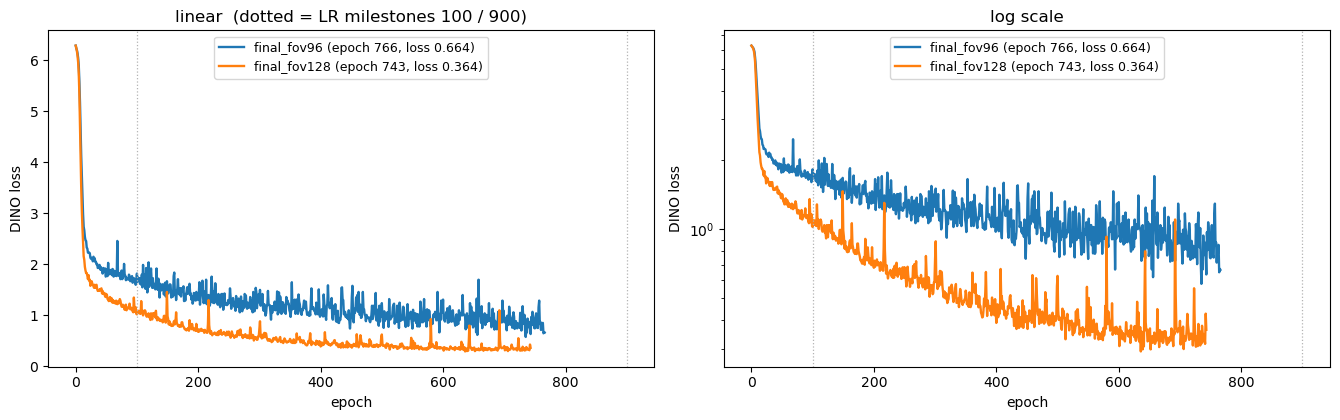

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
for ax, logy in zip(axes, [False, True]):
    for c in CONFIGS:
        lc = imc_tm.read_loss_curve(c, root=imc_tm.FINAL_RUN_DIR)
        if len(lc):
            ax.plot(
                lc["epoch"],
                lc["loss"],
                lw=1.7,
                label=f"{c} (epoch {int(lc['epoch'].max())}, loss {lc['loss'].iloc[-1]:.3f})",
            )
    for m in (100, 900):
        ax.axvline(m, color="0.7", lw=0.9, ls=":")
    ax.set_xlabel("epoch")
    ax.set_ylabel("DINO loss")
    ax.legend(fontsize=9)
    ax.set_title("log scale" if logy else "linear  (dotted = LR milestones 100 / 900)")
    if logy:
        ax.set_yscale("log")
plt.tight_layout()

## Featurise the training ROIs, under both filters

`flat10` matches training exactly and keeps every tile — the deployment view.
`scaled` uses 0.5× expected occupancy per FOV (29 cells at 96 µm, 52 at 128), which
equalises the *criterion* and is the fair cross-FOV comparison. A flat threshold is
relatively more permissive at large FOV, so it favours 128 µm.

Slow cell.

In [3]:
BIO_IDX = [imc_tm.CELL_TYPES.index(t) for t in imc_tm.BIOLOGY_TYPES]


def bio_frac(comp):
    b = np.asarray(comp)[:, BIO_IDX]
    return b / np.clip(b.sum(axis=1, keepdims=True), 1e-9, None)


def featurize(config, rois, h5ad_dir, fraction=None, epoch=EPOCH):
    spec = [s for s in imc_tm.FINAL_SWEEP if s["name"] == config][0]
    cfg = imc_tm.final_config_dict(spec)
    cfg["data_folder"] = str(h5ad_dir)
    cfg["n_element_min_for_crop"] = (
        10
        if fraction is None
        else imc_tm.fov_scaled_threshold(spec["fov_um"], fraction=fraction)
    )
    model = imc_tm.load_model(imc_tm.final_checkpoint(config, epoch=epoch))
    dm = imc_tm.make_datamodule(cfg)
    ad = {r: imc_tm.load_all_anndata(h5ad_dir)[r] for r in rois}
    res = imc_tm.featurize_windows(
        model, dm, ad, frac_overlap=0.0, seed=SEED, verbose=False
    )
    del model, dm
    return res, cfg["n_element_min_for_crop"]


def score(res, n_neighbors):
    lm = imc_tm.cluster_embedding_tm(
        res["features"], n_neighbors=n_neighbors, resolution=RESOLUTION, seed=SEED
    )["labels"]
    lc = imc_tm.cluster_embedding_tm(
        bio_frac(res["composition"]),
        n_neighbors=n_neighbors,
        resolution=RESOLUTION,
        seed=SEED,
    )["labels"]
    m = imc_tm.window_metrics(res, lm, k=4, n_perm=200, seed=SEED)
    mc = imc_tm.window_metrics(res, lc, k=4, n_perm=200, seed=SEED)
    bdf, bsum = imc_tm.border_cluster_report(res["centers_um"], res["roi"], lm)
    return (
        lm,
        lc,
        {
            "n_windows": m["n_windows"],
            "n_clusters": m["n_clusters"],
            "kappa": m["coherence_kappa"],
            "kappa_comp": mc["coherence_kappa"],
            "gain_x": imc_tm.safe_gain(m["coherence_kappa"], mc["coherence_kappa"]),
            "roi_mixing": m["roi_mixing"],
            "roimix_comp": mc["roi_mixing"],
            "border_clusters": bsum["n_border_clusters_ge80pct"],
            "worst_border": bsum["max_cluster_border_pct"],
        },
    )


train_res, train_lab, rows = {}, {}, []
for c in CONFIGS:
    for fname, frac in FILTERS.items():
        res, thr = featurize(
            c, imc_tm.FINAL_ROIS, imc_tm.final_h5ad_dir(c), fraction=frac
        )
        train_res[(c, fname)] = res
        for cname, nn in CLUSTERINGS.items():  # featurise once, cluster twice
            lm, lc, sc = score(res, nn)
            if cname == PRIMARY:
                train_lab[(c, fname)] = (lm, lc)
            rows.append(
                {"config": c, "filter": f"{fname}({thr})", "clust": cname, **sc}
            )
            print(
                f"  {c:<14s} {fname:<7s} thr {thr:3d} {cname:<6s} -> "
                f"{sc['n_windows']:5d} windows, {sc['n_clusters']:2d} clusters, gain {sc['gain_x']:.2f}x"
            )
train_met = pd.DataFrame(rows).set_index(["config", "filter", "clust"])
display(train_met.style.format(precision=3))

[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:92: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/sta

number of elements ---> 2632
mean and median spacing 8.839722603242338, 6.928202364723395
The dense shape of the image is -> torch.Size([10, 530, 530])


number of elements ---> 8920
mean and median spacing 6.531214259889485, 6.217716968208563
The dense shape of the image is -> torch.Size([10, 580, 580])


number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151
The dense shape of the image is -> torch.Size([10, 581, 581])


...

number of elements ---> 8724
mean and median spacing 6.807801972872951, 6.434931372051974
The dense shape of the image is -> torch.Size([10, 580, 581])


number of elements ---> 8250
mean and median spacing 6.682641894353679, 6.308046216872109
The dense shape of the image is -> torch.Size([10, 530, 531])


number of elements ---> 10597
mean and median spacing 5.94761912150776, 5.836300547191762
The dense shape of the image is -> torch.Size([10, 530, 532])


  final_fov128   scaled  thr  52 nn15   ->   502 windows, 14 clusters, gain 3.81x


  final_fov128   scaled  thr  52 nn100  ->   502 windows,  9 clusters, gain 2.70x


## Does it help on the *bad* ROIs?

Gain computed per ROI. The whole point of adding JHH357ROI5 (2.2% biology) and
JHH317ROI2 (2,643 cells/mm²) was to find out whether the model degrades on poor input
or handles it. Spatial coherence needs neighbours, so this restricts the neighbour
pairs to within each ROI rather than subsetting the grid.

In [4]:
from scipy.spatial import cKDTree


def coherence_one_roi(res, labels, roi, n_perm=200, seed=SEED):
    m = np.flatnonzero(res["roi"] == roi)
    if len(m) < 20:
        return np.nan
    sub_c, sub_l = res["centers_um"][m], np.asarray(labels)[m]
    rng = np.random.default_rng(seed)
    tree = cKDTree(sub_c)
    _, idx = tree.query(sub_c, k=min(4, len(m) - 1) + 1)
    pairs = np.array([(a, b) for a, row in enumerate(idx) for b in row[1:]])
    obs = float((sub_l[pairs[:, 0]] == sub_l[pairs[:, 1]]).mean())
    null = np.array(
        [
            (lambda sh: (sh[pairs[:, 0]] == sh[pairs[:, 1]]).mean())(
                rng.permutation(sub_l)
            )
            for _ in range(n_perm)
        ]
    )
    mu = float(null.mean())
    return (obs - mu) / (1.0 - mu) if mu < 1 else np.nan


qual = {
    "JHH387ROI1": "high",
    "JHH380ROI1": "high",
    "JHH357ROI5": "low: signal-poor",
    "JHH317ROI2": "low: sparse",
}
rows = []
for c in CONFIGS:
    res = train_res[(c, "flat10")]
    lm, lc = train_lab[(c, "flat10")]
    for roi in imc_tm.FINAL_ROIS:
        km = coherence_one_roi(res, lm, roi)
        kc = coherence_one_roi(res, lc, roi)
        rows.append(
            {
                "config": c,
                "roi": roi,
                "role": qual.get(roi, "JHH369 baseline"),
                "n_win": int((res["roi"] == roi).sum()),
                "med_cells": float(np.median(res["n_cells"][res["roi"] == roi])),
                "kappa": km,
                "kappa_comp": kc,
                "gain_x": imc_tm.safe_gain(km, kc),
            }
        )
per_roi = pd.DataFrame(rows)
for c in CONFIGS:
    print(f"=== {c} ===")
    print(
        per_roi[per_roi.config == c]
        .drop(columns="config")
        .to_string(index=False, float_format=lambda v: f"{v:.3f}")
    )
    print()

=== final_fov96 ===
       roi             role  n_win  med_cells  kappa  kappa_comp  gain_x
JHH369ROI1  JHH369 baseline    151     56.000  0.205       0.085   2.411
JHH369ROI2  JHH369 baseline    143     44.000  0.256       0.127   2.014
JHH369ROI3  JHH369 baseline    144     53.000  0.322       0.196   1.646
JHH369ROI4  JHH369 baseline    144     63.000  0.183       0.128   1.430
JHH387ROI1             high    123     85.000  0.190       0.065   2.902
JHH380ROI1             high    121     74.000  0.373       0.151   2.475
JHH357ROI5 low: signal-poor    144     59.000  0.159       0.075   2.108
JHH317ROI2      low: sparse     83     18.000  0.230       0.047   4.944

=== final_fov128 ===
       roi             role  n_win  med_cells  kappa  kappa_comp  gain_x
JHH369ROI1  JHH369 baseline     91     99.000  0.362       0.144   2.517
JHH369ROI2  JHH369 baseline     88     74.000  0.492       0.163   3.019
JHH369ROI3  JHH369 baseline     82     92.500  0.489       0.191   2.555
JHH369ROI

## The transfer test

Featurise the 40 untrained ROIs and score the two tiers separately. This is the number
that decides whether the model is usable on the cohort, and the one the single-patient
model failed: **gain below 1.0 means the embedding is worse than clustering cell
counts.**

Slow cell — 40 ROIs.

In [5]:
# train_p = {imc_tm.roi_to_patient(r) for r in imc_tm.FINAL_ROIS}
# held = imc_tm.heldout_rois()
# tiers = {
#     "held-out, seen patient":   [r for r in held if imc_tm.roi_to_patient(r) in train_p],
#     "held-out, unseen patient": [r for r in held if imc_tm.roi_to_patient(r) not in train_p],
# }
# rows, held_res = [], {}
# for c in CONFIGS:
#     for tname, rois in tiers.items():
#         res, thr = featurize(c, rois, imc_tm.H5AD_DIR, fraction=None)
#         for cname, nn in CLUSTERINGS.items():
#             lm, lc, sc = score(res, nn)
#             if cname == PRIMARY:
#                 held_res[(c, tname)] = (res, lm)
#             rows.append({"config": c, "tier": tname, "clust": cname, "n_rois": len(rois),
#                          "n_patients": len({imc_tm.roi_to_patient(r) for r in rois}), **sc})
#             print(f"  {c:<14s} {tname:<26s} {cname:<6s} {sc['n_windows']:5d} windows, "
#                   f"gain {sc['gain_x']:.2f}x")
# transfer = pd.DataFrame(rows).set_index(["config", "tier", "clust"])
# display(transfer.style.format(precision=3))

In [6]:
# fig, ax = plt.subplots(figsize=(9, 4.4))
# order = ["training", "held-out, seen patient", "held-out, unseen patient"]
# for c, mk in zip(CONFIGS, ["-o", "-s"]):
#     vals = [train_met.loc[(c, "flat10(10)", PRIMARY), "gain_x"]] + \
#            [transfer.loc[(c, t, PRIMARY), "gain_x"] for t in order[1:]]
#     ax.plot(range(3), vals, mk, lw=2, label=c)
#     for x, v in enumerate(vals):
#         ax.annotate(f"{v:.2f}x", (x, v), textcoords="offset points", xytext=(0, 9),
#                     ha="center", fontsize=9)
# ax.axhline(1.0, color="crimson", lw=1.2, ls="--", label="no gain over counting")
# ax.set_xticks(range(3)); ax.set_xticklabels(order, fontsize=9)
# ax.set_ylabel("gain over composition baseline"); ax.grid(alpha=0.3); ax.legend(fontsize=9)
# ax.set_title("Does the embedding survive leaving the training set?")
# plt.tight_layout()
# print("Single-patient reference (S1 config A): 0.78x on dense unseen ROIs, 0.33x on sparse.")
# print("Anything at or below the crimson line is worse than clustering cell counts.")

## UMAPs and tissue maps (training ROIs, flat 10)

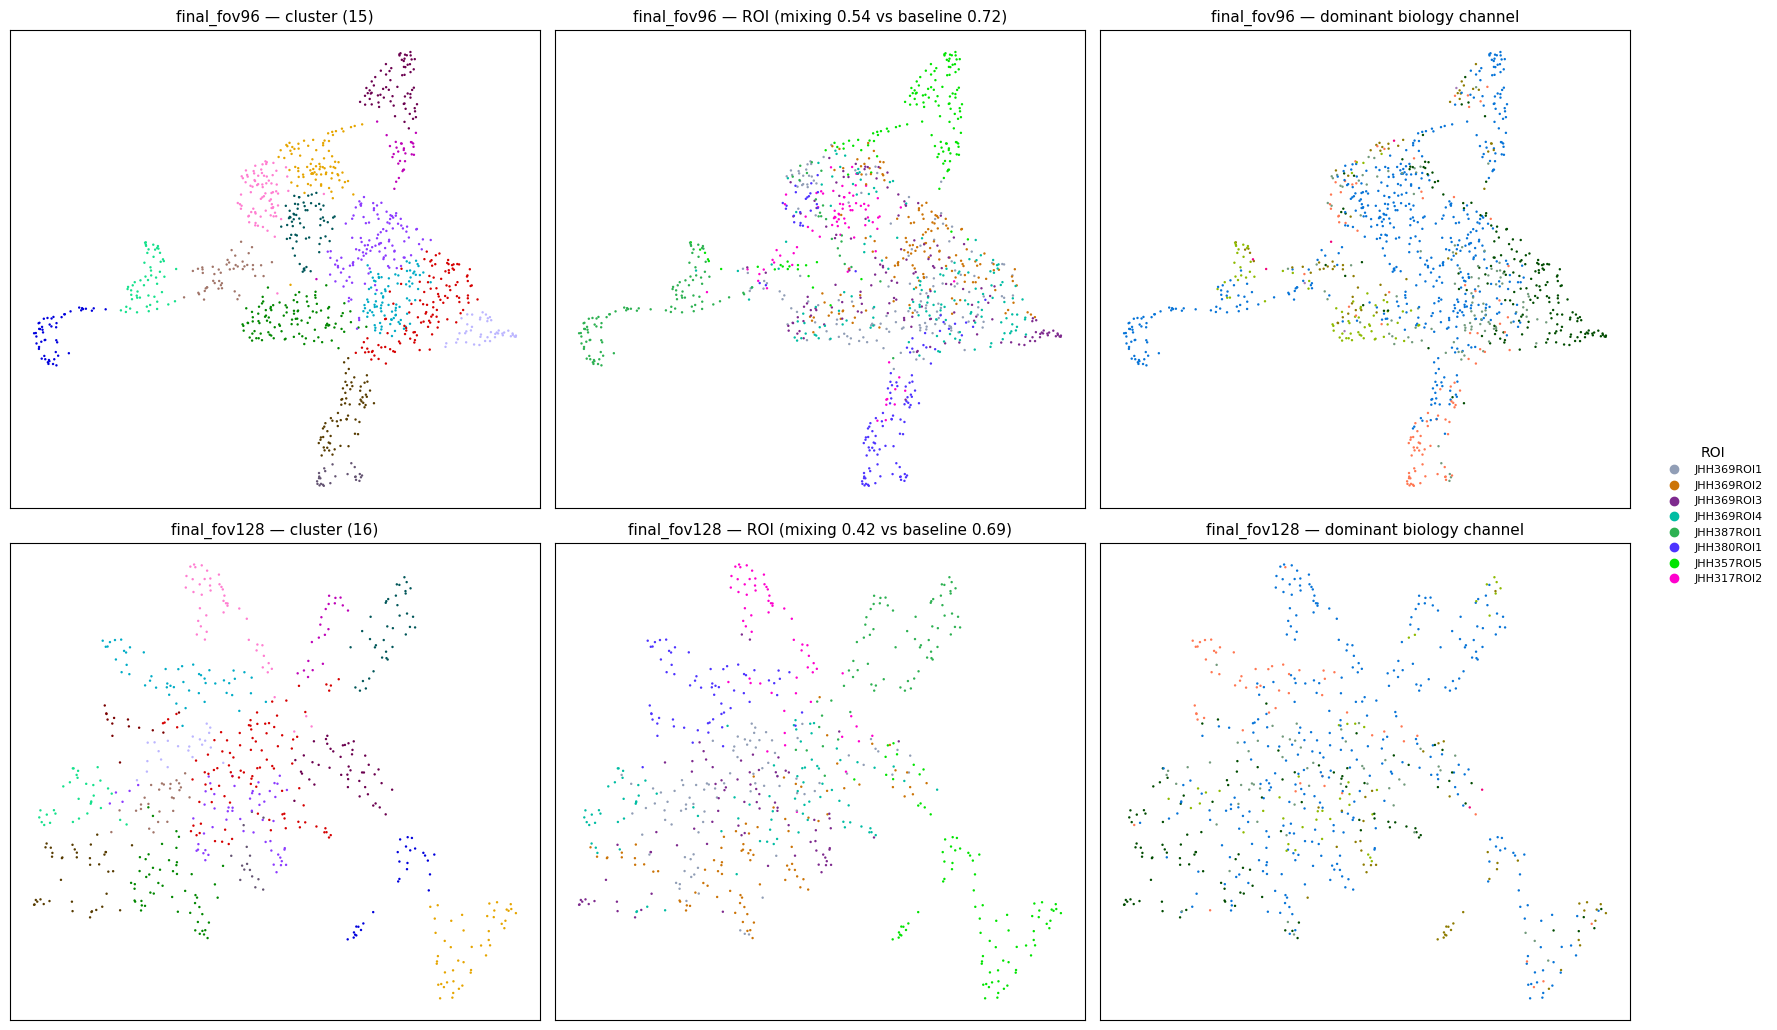

In [7]:
rc = imc_tm.roi_palette(imc_tm.FINAL_ROIS)
pal = imc_tm.palette()
fig, axes = plt.subplots(len(CONFIGS), 3, figsize=(16.5, 5.2 * len(CONFIGS)))
for i, c in enumerate(CONFIGS):
    res = train_res[(c, "flat10")]
    lm, _ = train_lab[(c, "flat10")]
    u = imc_tm.cluster_embedding_tm(
        res["features"],
        n_neighbors=CLUSTERINGS[PRIMARY],
        resolution=RESOLUTION,
        seed=SEED,
    )["umap"]
    cc = imc_tm.cluster_palette(labels=sorted(np.unique(lm)))
    dom = np.array(imc_tm.BIOLOGY_TYPES)[bio_frac(res["composition"]).argmax(axis=1)]
    axes[i, 0].scatter(u[:, 0], u[:, 1], color=[cc[x] for x in lm], s=3, linewidths=0)
    axes[i, 0].set_title(f"{c} — cluster ({len(np.unique(lm))})", fontsize=11)
    axes[i, 1].scatter(
        u[:, 0], u[:, 1], color=[rc[r] for r in res["roi"]], s=3, linewidths=0
    )
    axes[i, 1].set_title(
        f"{c} — ROI (mixing {train_met.loc[(c, 'flat10(10)', PRIMARY), 'roi_mixing']:.2f} "
        f"vs baseline {train_met.loc[(c, 'flat10(10)', PRIMARY), 'roimix_comp']:.2f})",
        fontsize=11,
    )
    axes[i, 2].scatter(u[:, 0], u[:, 1], color=[pal[t] for t in dom], s=3, linewidths=0)
    axes[i, 2].set_title(f"{c} — dominant biology channel", fontsize=11)
    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])
h = [
    plt.Line2D([0], [0], marker="o", ls="", ms=6, color=rc[r], label=r)
    for r in imc_tm.FINAL_ROIS
]
fig.legend(
    handles=h,
    bbox_to_anchor=(1.005, 0.5),
    loc="center left",
    fontsize=8,
    frameon=False,
    title="ROI",
)
plt.tight_layout()

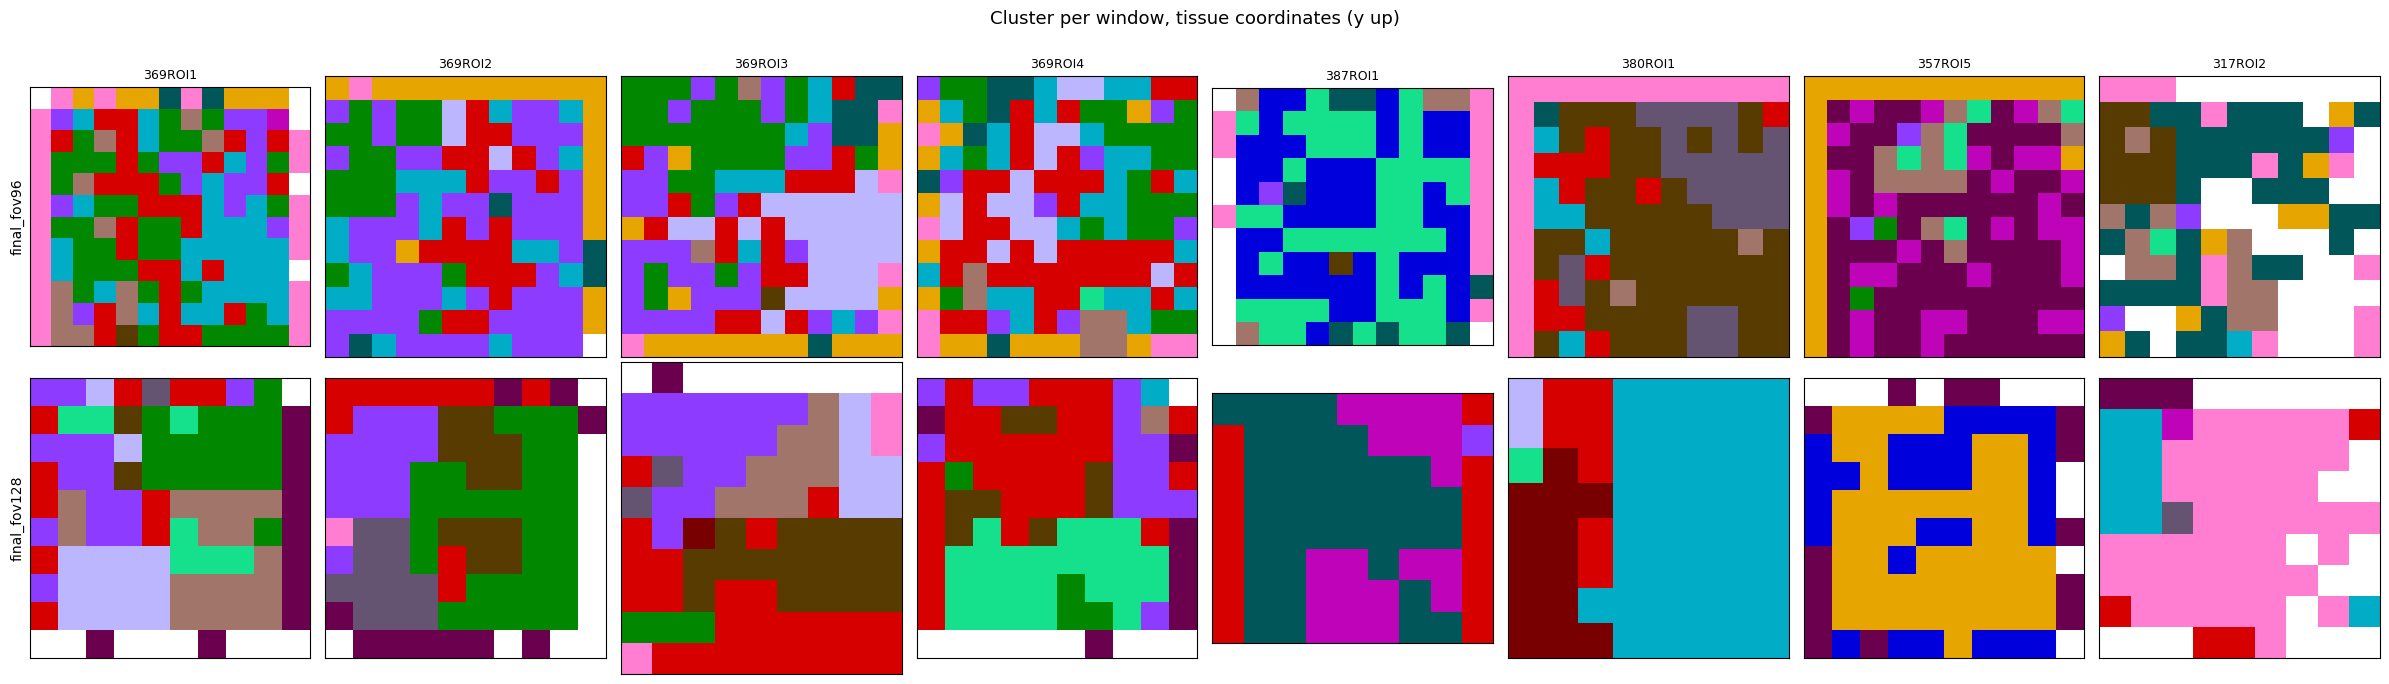

In [8]:
ROIS = imc_tm.FINAL_ROIS
fig, axes = plt.subplots(
    len(CONFIGS), len(ROIS), figsize=(3.0 * len(ROIS), 3.4 * len(CONFIGS))
)
for i, c in enumerate(CONFIGS):
    res = train_res[(c, "flat10")]
    lm, _ = train_lab[(c, "flat10")]
    cc = imc_tm.cluster_palette(labels=sorted(np.unique(lm)))
    fov = [s for s in imc_tm.FINAL_SWEEP if s["name"] == c][0]["fov_um"]
    for j, r in enumerate(ROIS):
        m = res["roi"] == r
        imc_tm.plot_window_map(
            axes[i, j], res["centers_um"][m], [cc[x] for x in lm[m]], fov
        )
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(r.replace("JHH", ""), fontsize=9)
    axes[i, 0].set_ylabel(c, fontsize=10)
plt.suptitle("Cluster per window, tissue coordinates (y up)", y=1.002, fontsize=13)
plt.tight_layout()

## Reading it

1. **Transfer plot first.** If `gain` on unseen patients is above 1.0, five patients
   fixed what one could not, and the model is usable cohort-wide. If it is still below
   1.0, the problem is not data diversity and no amount of extra ROIs will fix it —
   the next move would be a different objective or a shorter effective scale, not more
   data.
2. **Per-ROI table.** Does the model earn its gain evenly, or only on the good ROIs?
   Degradation confined to JHH357ROI5 means signal-poor input is the limit; confined to
   JHH317ROI2 means sparsity is.
3. **Both filters.** `flat10` favours 128 µm by construction. If 128 wins under
   `scaled` too, the margin is real.
4. **Border clusters.** At threshold 10 expect roughly one artefact cluster per run;
   check `worst_border` before reading cluster identities as biology.

Caveats:

- **`ckpt_last.pt` only exists after all 1000 epochs.** Set `EPOCH` to a periodic
  checkpoint to evaluate mid-run; the schedule's decay tail runs 900→1000, so a model
  read before epoch 900 has not consolidated and will understate final quality.
- **Held-out ROIs share the cohort's preprocessing**, not just its biology. A gain drop
  at tier 3 is patient-level, but that still bundles biology, staining batch and
  section quality — this design cannot separate those three.